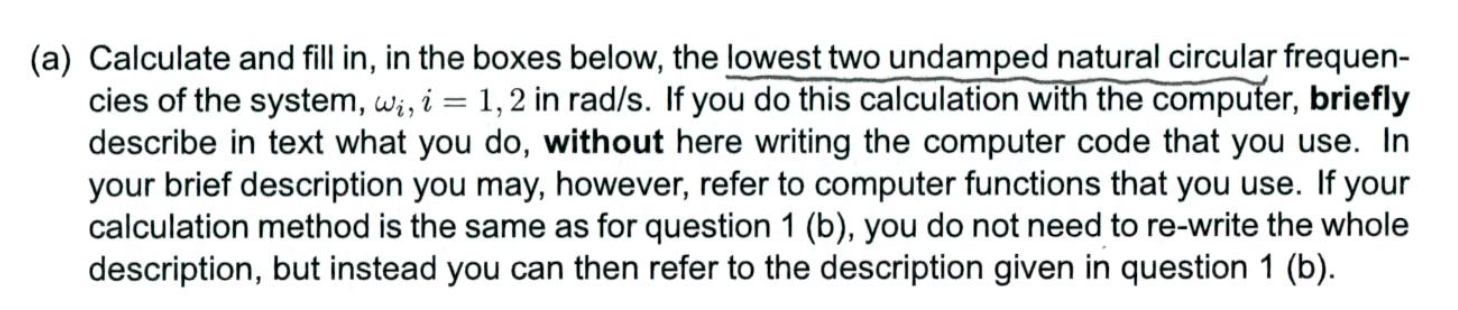
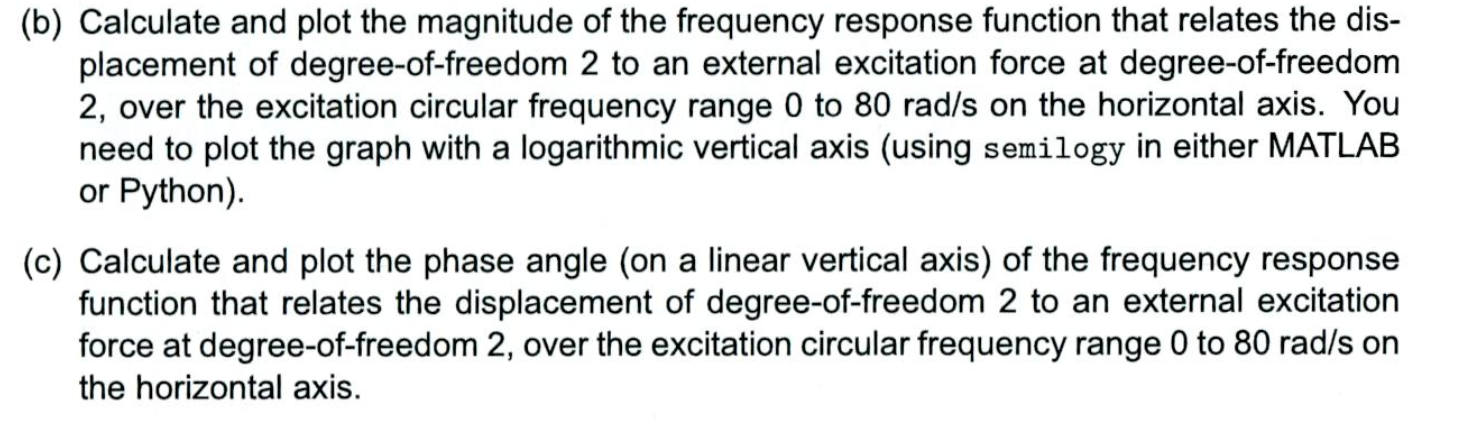

In [26]:
from pandas import read_excel
from printarray import printarray
import numpy as np
from numpy import sqrt, pi, dot, deg2rad, rad2deg
from numpy.linalg import eig, inv, det, norm
import math
from matplotlib import pyplot as plt
from scipy.signal import argrelextrema

KDF = read_excel('stiffness_matrix.xlsx')
MDF = read_excel('mass_matrix.xlsx')
CDF = read_excel('damping_matrix.xlsx')
K = KDF.values
M = MDF.values
C = CDF.values

# ==========================================
#           用户配置区域 (请在此修改)
# ==========================================

# 1. 定义系统矩阵 (示例：一个简单的3自由度系统)
# 请务必替换为你题目中的真实数据！
'''
M = np.array([
    [2, 0, 0],
    [0, 2, 0],
    [0, 0, 2]
])

K = np.array([
    [2000, -1000, 0],
    [-1000, 2000, -1000],
    [0, -1000, 2000]
])

C = np.array([
    [2, -1, 0],
    [-1, 2, -1],
    [0, -1, 2]
])
'''
# 2. 定义题目要求的参数
FREQ_RANGE_MAX = 80.0  # 频率范围
NUM_POINTS = 2000      # 计算点数
CHECK_RANGE_MAX = 80.0
# ★★★ 核心修改区域 ★★★
# 分别定义 "响应自由度" 和 "激振自由度"
# 题目示例：Calculate response at DOF 2 due to force at DOF 1
RESPONSE_DOF = 2    # i: 测量位移的地方
FORCE_DOF    = 2    # j: 施加力的地方 (如果题目要求不同，这里改成不同的数字)

# 自动转换为 Python 索引 (从0开始)
# H_ij: i行j列 -> row=response, col=force
resp_idx = RESPONSE_DOF - 1
force_idx = FORCE_DOF - 1

# 3. 额外计算配置 (应对突发提问)
SPECIFIC_FREQ = 20.0   # 特定频率 (rad/s)
FORCE_AMPLITUDE = 1.0  # 激振力幅值 (N)

print(f"--- 系统分析开始 ---")
print(f"目标: 计算 H_{{{RESPONSE_DOF}{FORCE_DOF}}} (响应 @ DOF {RESPONSE_DOF} / 激振 @ DOF {FORCE_DOF})\n")

# ==========================================
#        (a) 计算最低的两阶无阻尼固有频率
# ==========================================
evals, evecs = eigh(K, M)
omega_n = np.sqrt(np.abs(evals))
omega_n_sorted = np.sort(omega_n)

print(f">>> 题目 (a) 结果:")
print(f"最低两阶固有频率 w_1 = {omega_n_sorted[0]:.4f} rad/s")
print(f"最低两阶固有频率 w_2 = {omega_n_sorted[1]:.4f} rad/s")
print("-" * 30)

# ==========================================
#    计算跨点频响函数 (Cross-Point FRF)
# ==========================================
omegas = np.linspace(0, FREQ_RANGE_MAX, NUM_POINTS)
magnitudes = []  
phases = []      

# 用于特定频率的计算
specific_H_val = None

for w in omegas:
    # 动刚度矩阵 Z(w) = K - w^2*M + i*w*C
    Z = K - (w**2) * M + 1j * w * C
    
    # 计算频响函数矩阵 H(w) = inv(Z)
    H = inv(Z)
    
    # ★★★ 关键修改 ★★★
    # 提取 H_ij: 第 i 行 (响应), 第 j 列 (激励)
    # H[row, col] -> H[resp_idx, force_idx]
    h_val = H[resp_idx, force_idx]
    
    magnitudes.append(np.abs(h_val))
    phases.append(np.rad2deg(np.angle(h_val)))

# 单独精确计算特定频率 (避免插值误差)
Z_spec = K - (SPECIFIC_FREQ**2) * M + 1j * SPECIFIC_FREQ * C
H_spec = inv(Z_spec)
specific_H_val = H_spec[resp_idx, force_idx]





--- 系统分析开始 ---
目标: 计算 H_{22} (响应 @ DOF 2 / 激振 @ DOF 2)

>>> 题目 (a) 结果:
最低两阶固有频率 w_1 = 6.5140 rad/s
最低两阶固有频率 w_2 = 12.5430 rad/s
------------------------------


>>> 正在生成题目 (b) 和 (c) 的图表...


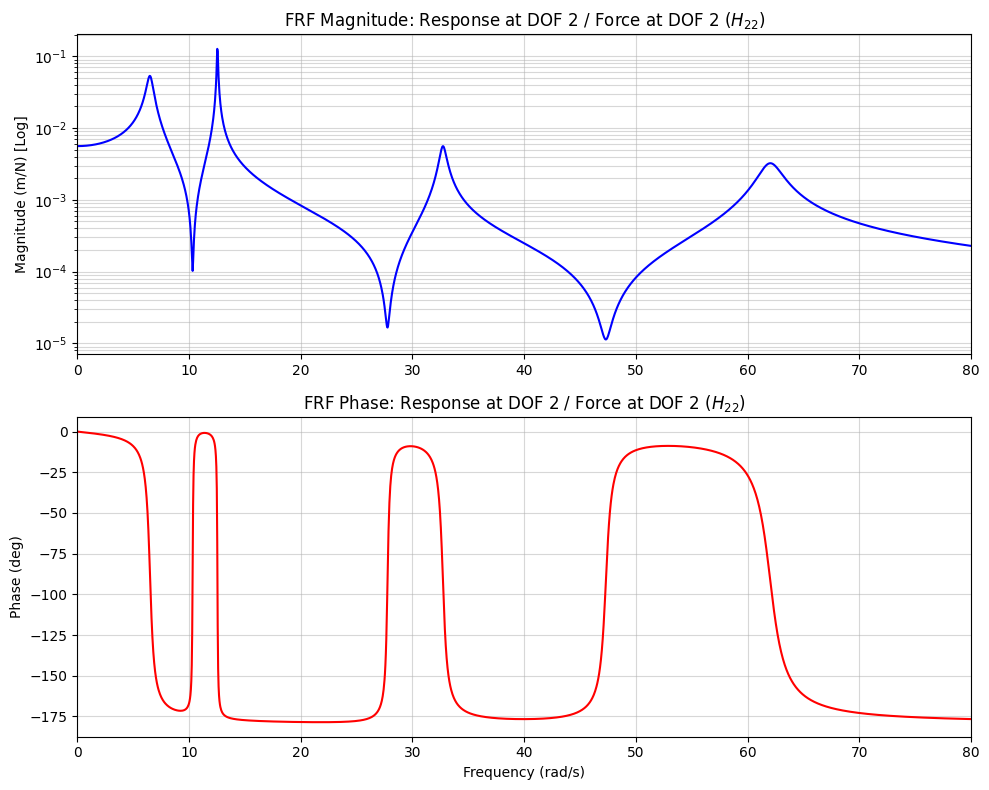


      额外计算结果 (H_{22})

[1] 在特定频率 w = 20.0 rad/s 下:
    - FRF 幅值 (Magnitude): 8.348576e-04 m/N
    - 相位 (Phase):         -178.4766 degrees
    - 峰峰值位移 (Peak-to-Peak): 1.669715e-03 m
      (响应点: 2, 激振点: 2, 力: 1.0 N)

[2] 反共振频率检测 (Antiresonance Frequencies):
    - 发现反共振点: w = 10.3252 rad/s (幅值: 1.02e-04)
    - 发现反共振点: w = 27.7739 rad/s (幅值: 1.66e-05)
    - 发现反共振点: w = 47.3037 rad/s (幅值: 1.13e-05)



In [27]:
# ==========================================
#        (b) & (c) 绘图 (自动适配标题)
# ==========================================
print(">>> 正在生成题目 (b) 和 (c) 的图表...")
plt.figure(figsize=(10, 8))

# 标题字符串
title_str = f'Response at DOF {RESPONSE_DOF} / Force at DOF {FORCE_DOF} ($H_{{{RESPONSE_DOF}{FORCE_DOF}}}$)'

plt.subplot(2, 1, 1)
plt.semilogy(omegas, magnitudes, 'b-', linewidth=1.5)
plt.title(f'FRF Magnitude: {title_str}')
plt.ylabel('Magnitude (m/N) [Log]')
plt.grid(True, which="both", alpha=0.5)
plt.xlim(0, FREQ_RANGE_MAX)

plt.subplot(2, 1, 2)
plt.plot(omegas, phases, 'r-', linewidth=1.5)
plt.title(f'FRF Phase: {title_str}')
plt.ylabel('Phase (deg)')
plt.xlabel('Frequency (rad/s)')
plt.grid(True, which="both", alpha=0.5)
plt.xlim(0, FREQ_RANGE_MAX)

plt.tight_layout()
plt.show()

# ==========================================
#      ★ 额外计算结果 (支持不同DOF) ★
# ==========================================
print("\n" + "="*40)
print(f"      额外计算结果 (H_{{{RESPONSE_DOF}{FORCE_DOF}}})")
print("="*40)

# 1. 输出特定频率下的 Phase 和 Peak-to-Peak
spec_mag = np.abs(specific_H_val)        
spec_phase = np.rad2deg(np.angle(specific_H_val)) 

# Peak-to-Peak 位移计算公式: 2 * 幅值 * 力
peak_to_peak = 2 * spec_mag * FORCE_AMPLITUDE 

print(f"\n[1] 在特定频率 w = {SPECIFIC_FREQ} rad/s 下:")
print(f"    - FRF 幅值 (Magnitude): {spec_mag:.6e} m/N")
print(f"    - 相位 (Phase):         {spec_phase:.4f} degrees")
print(f"    - 峰峰值位移 (Peak-to-Peak): {peak_to_peak:.6e} m")
print(f"      (响应点: {RESPONSE_DOF}, 激振点: {FORCE_DOF}, 力: {FORCE_AMPLITUDE} N)")

# 2. 计算反共振频率 (Antiresonance)
magnitudes_arr = np.array(magnitudes)
min_indices = argrelextrema(magnitudes_arr, np.less)[0]

print(f"\n[2] 反共振频率检测 (Antiresonance Frequencies):")
if len(min_indices) > 0:
    for idx in min_indices:
        w_anti = omegas[idx]
        mag_anti = magnitudes[idx]
        if w_anti > 0.1: 
            print(f"    - 发现反共振点: w = {w_anti:.4f} rad/s (幅值: {mag_anti:.2e})")
else:
    print("    - 未在当前频率范围内检测到明显的反共振点。")

print("\n" + "="*40)


In [28]:
# ==========================================
#        (d) 确定动态响应 > 静态变形的范围
# ==========================================
print("\n" + "="*50)
print(">>> (d) Ranges where Dynamic Response > Static Deflection")
print("="*50)

# 1. 获取静态变形 (Static Deflection)
# 即频率为 0 时的幅值
static_deflection = magnitudes[0]
print(f"1. Static Deflection (at w=0): {static_deflection:.6e} m/N")

# 2. 找出满足条件的索引
# 条件：(频率 < 30) 且 (幅值 > 静态变形)
# np.where 返回满足条件的索引数组
condition_indices = np.where((omegas < CHECK_RANGE_MAX) & (magnitudes > static_deflection))[0]

if len(condition_indices) == 0:
    print("   没有找到符合条件的范围。")
else:
    # 3. 将连续的索引合并成范围 (Range)
    # 这是一个常用的小算法：如果 index[i+1] != index[i] + 1，说明断开了
    ranges = []
    if len(condition_indices) > 0:
        start_idx = condition_indices[0]
        prev_idx = condition_indices[0]
        
        for idx in condition_indices[1:]:
            if idx > prev_idx + 1:
                # 发现断点，保存上一段范围
                ranges.append((omegas[start_idx], omegas[prev_idx]))
                start_idx = idx
            prev_idx = idx
        # 保存最后一段
        ranges.append((omegas[start_idx], omegas[prev_idx]))

    # 4. 打印结果
    print(f"2. 在 0 到 {CHECK_RANGE_MAX} rad/s 范围内，满足条件的区间为:")
    for i, (start_w, end_w) in enumerate(ranges):
        print(f"   [Box {i+1}]: {start_w:.2f} rad/s  to  {end_w:.2f} rad/s")

# ==========================================
#    Briefly Description (你可以参考这段文字)
# ==========================================
print("\n[Brief Description Reference for (d)]")
print("To determine these ranges, I first calculated the static deflection, which corresponds to the magnitude of the frequency response function at zero frequency (w=0).")
print("I then inspected the computed FRF magnitude data in the range 0 < w < 30 rad/s.")
print("Finally, I identified the frequency intervals where the FRF magnitude value was strictly greater than the static deflection value.")


>>> (d) Ranges where Dynamic Response > Static Deflection
1. Static Deflection (at w=0): 5.599325e-03 m/N
2. 在 0 到 80.0 rad/s 范围内，满足条件的区间为:
   [Box 1]: 0.04 rad/s  to  8.24 rad/s
   [Box 2]: 11.77 rad/s  to  13.69 rad/s

[Brief Description Reference for (d)]
To determine these ranges, I first calculated the static deflection, which corresponds to the magnitude of the frequency response function at zero frequency (w=0).
I then inspected the computed FRF magnitude data in the range 0 < w < 30 rad/s.
Finally, I identified the frequency intervals where the FRF magnitude value was strictly greater than the static deflection value.
